In [1]:
%cd ../

/media/edwardl.campbell/D/code/sst


# Possible improvements
### ASR
- Use pruna on whisper model https://docs.pruna.ai/en/v0.1.3/tutorials_nb/asr_whisper.html
- Semantic Endpointing (where the system checks if the transcribed text forms a complete grammatical sentence before cutting off the user)
- Low dictionary to improve WER in this scenarios
- - onnxruntime for production readiness of silero-VAD and anything else we would need
### Agent
- If we identify there will be a delay to answer the receive query because of the need to call a tool, we return a query to announce the waiting time and the actions we are performing.
- Deploy agent and connect it to the UI (step bellow)
- Add langraph UI for chats (https://docs.langchain.com/oss/python/langgraph/ui)

## Real-Time STT

In [2]:
import torch
import numpy as np
import pandas as pd
import librosa
import time
import warnings
from typing import Dict, Any, Tuple, List
from faster_whisper import WhisperModel

# Suppress librosa PySoundFile warning for clean terminal output
warnings.filterwarnings("ignore", category=UserWarning, module='librosa')

# --- Configuration ---
AUDIO_FILE = "/media/edwardl.campbell/D/Data-io/sps-corpus-1.0-2025-11-25-en/audios/spontaneous-speech-en-67856.mp3"
#"/media/edwardl.campbell/D/Data-io/sps-corpus-1.0-2025-11-25-en/audios/spontaneous-speech-en-68243.mp3"

SAMPLE_RATE = 16000          # Silero and Whisper strictly require 16kHz
WINDOW_SIZE_SAMPLES = 512    # Exactly 32ms at 16kHz. Required by Silero VAD.
SILENCE_GAP_SECONDS = 0.8   # The threshold defining the end of an utterance 0.8
VAD_THRESHOLD = 0.4          # Probability threshold for speech (0.0 to 1.0)
MODEL_SIZE = "base"
DEVICE = "cuda"              # Switch to "cpu" if not running on Nvidia GPU
COMPUTE_TYPE = "float16"     # Switch to "int8" if running on CPU


def load_models() -> Tuple[WhisperModel, Any]:
    """Initializes and returns the ASR and VAD models."""
    print(f"Loading Whisper '{MODEL_SIZE}' model on {DEVICE.upper()}...")
    asr_model = WhisperModel(MODEL_SIZE, device=DEVICE, compute_type=COMPUTE_TYPE)

    print("Loading Silero VAD model...")
    vad_model, utils = torch.hub.load(
        repo_or_dir='snakers4/silero-vad',
        model='silero_vad',
        force_reload=False,
        trust_repo=True,
        verbose=False
    )
    vad_model.eval()
    print("Models loaded successfully.\n" + "-" * 40)

    return asr_model, vad_model


def transcribe_audio_with_metrics(
    model: WhisperModel,
    audio_data: np.ndarray,
    sample_rate: int,
    chunk_start_time: float
) -> Tuple[str, List[Dict[str, Any]], Dict[str, float]]:
    """
    Transcribes audio, extracts word timestamps, and calculates exact End-Point Latency and RTF.
    """
    start_transcription = time.time()

    segments, info = model.transcribe(
        audio_data,
        beam_size=1,
        language="en",
        word_timestamps=True,
        vad_filter=False # Silero handles VAD externally
    )

    inference_time_s = time.time() - start_transcription
    audio_duration_s = len(audio_data) / sample_rate

    words_data = []
    full_text = ""
    last_word_end_relative = 0.0

    for segment in segments:
        for word in segment.words:
            abs_start = chunk_start_time + word.start
            abs_end = chunk_start_time + word.end
            last_word_end_relative = word.end

            words_data.append({
                "word": word.word.strip(),
                "start": abs_start,
                "end": abs_end,
                "confidence": word.probability
            })
            full_text += word.word + " "

    # ---------------------------------------------------------
    # EXACT END-POINT LATENCY COMPUTATION
    # ---------------------------------------------------------
    if words_data:
        # Time from the exact end of the final spoken word to the text being available
        endpoint_latency_s = (audio_duration_s + inference_time_s) - last_word_end_relative
    else:
        # Fallback for empty/hallucinated segments
        endpoint_latency_s = audio_duration_s + inference_time_s

    rtf = inference_time_s / audio_duration_s if audio_duration_s > 0 else 0

    metrics = {
        "inference_time_ms": inference_time_s * 1000,
        "audio_duration_s": audio_duration_s,
        "rtf": rtf,
        "endpoint_latency_ms": endpoint_latency_s * 1000
    }

    return full_text.strip(), words_data, metrics


def process_utterance(
    asr_model: WhisperModel,
    buffer: List[float],
    sample_rate: int,
    start_time: float,
    verbose: bool
) -> Dict[str, Any]:
    """Helper function to process a sealed buffer and return a structured record."""
    buffer_np = np.ascontiguousarray(np.array(buffer, dtype=np.float32))

    if verbose:
        print(f"\n[EVENT] Utterance Captured: {start_time:.2f}s")

    text, words_data, metrics = transcribe_audio_with_metrics(
        asr_model,
        buffer_np,
        sample_rate,
        chunk_start_time=start_time
    )

    if verbose:
        print(f"  Transcription: \"{text}\"" if text else "  Transcription: [Ignored / Silence]")
        if text:
            print(f"  --- Subsystem Metrics ---")
            print(f"    Audio Processed:      {metrics['audio_duration_s']:.2f} s")
            print(f"    Model Inference Time: {metrics['inference_time_ms']:.0f} ms")
            print(f"    RTF:                  {metrics['rtf']:.3f}x")
            print(f"    End-Point Latency:    {metrics['endpoint_latency_ms']:.0f} ms")

    # Return a flat dictionary ready for a Pandas DataFrame row
    return {
        "utt": text,
        "words_data": words_data,
        "audio_duration_s": metrics['audio_duration_s'],
        "inference_time_ms": metrics['inference_time_ms'],
        "rtf": metrics['rtf'],
        "endpoint_latency_ms": metrics['endpoint_latency_ms']
    }


def run_STT_pipeline(
    audio_path: str,
    asr_model: WhisperModel,
    vad_model: Any,
    verbose: bool = True
) -> pd.DataFrame:
    """Executes the streaming STT simulation pipeline."""
    print(f"Loading and resampling audio to {SAMPLE_RATE}Hz: {audio_path}")
    records = []

    try:
        audio_data, _ = librosa.load(audio_path, sr=SAMPLE_RATE, mono=True)

        silence_limit_chunks = int(SILENCE_GAP_SECONDS / (WINDOW_SIZE_SAMPLES / SAMPLE_RATE))
        total_samples = len(audio_data)

        utterance_buffer = []
        continuous_silence_chunks = 0
        is_recording_utterance = False
        utterance_start_time = 0.0

        vad_model.reset_states()

        for i in range(0, total_samples, WINDOW_SIZE_SAMPLES):
            chunk = audio_data[i:i + WINDOW_SIZE_SAMPLES]

            # Pad final chunk if necessary
            if len(chunk) < WINDOW_SIZE_SAMPLES:
                 pad_width = WINDOW_SIZE_SAMPLES - len(chunk)
                 chunk = np.pad(chunk, (0, pad_width), mode='constant')

            chunk_tensor = torch.from_numpy(chunk).float()

            with torch.no_grad():
                speech_prob = vad_model(chunk_tensor, SAMPLE_RATE).item()

            if speech_prob > VAD_THRESHOLD:
                if not is_recording_utterance:
                    is_recording_utterance = True
                    utterance_start_time = i / SAMPLE_RATE

                continuous_silence_chunks = 0
                utterance_buffer.extend(chunk)

            elif is_recording_utterance:
                continuous_silence_chunks += 1
                utterance_buffer.extend(chunk)

                # Utterance strictly completes here
                if continuous_silence_chunks >= silence_limit_chunks:
                    record = process_utterance(
                        asr_model, utterance_buffer, SAMPLE_RATE,
                        utterance_start_time, verbose=verbose
                    )
                    # Only append if text was actually recognized
                    if record["utt"]:
                        records.append(record)

                    # Reset states
                    utterance_buffer = []
                    continuous_silence_chunks = 0
                    is_recording_utterance = False
                    vad_model.reset_states()

        # Handle End of File flush
        if is_recording_utterance and len(utterance_buffer) > SAMPLE_RATE * 0.5:
            record = process_utterance(
                asr_model, utterance_buffer, SAMPLE_RATE,
                utterance_start_time, verbose=verbose
            )
            if record["utt"]:
                records.append(record)

        # Build and return the DataFrame cleanly
        stt_info_df = pd.DataFrame(records)
        return stt_info_df

    except FileNotFoundError:
        print(f"Error: Audio file '{audio_path}' not found.")
        return pd.DataFrame()
    except Exception as e:
        print(f"An error occurred during processing: {e}")
        return pd.DataFrame()


if __name__ == "__main__":
    # 1. Initialize dependencies
    asr_model, vad_model = load_models()

    # 2. Run pipeline (set verbose=True to see the real-time event logs)
    df_results = run_STT_pipeline(AUDIO_FILE, asr_model, vad_model, verbose=False)

    # 3. Display summary
    print("\n" + "="*50)
    print("FINAL DATAFRAME RESULTS")
    print("="*50)
    if not df_results.empty:
        for i, row in df_results.iterrows():
            print(f"Utt {i}: \"{row['utt']}\"")
            print(f"End-Point Latency: {row['endpoint_latency_ms']:.0f} ms")
            print(f"ASR inference time: {row['inference_time_ms']:.0f} ms | RTF: {row['rtf']:.6f} ms")
            print(f"Duration:          {row['audio_duration_s']:.2f} s")
            print("-" * 30)
    else:
        print("No speech detected or processing failed.")

Loading Whisper 'base' model on CUDA...
Loading Silero VAD model...
Models loaded successfully.
----------------------------------------
Loading and resampling audio to 16000Hz: /media/edwardl.campbell/D/Data-io/sps-corpus-1.0-2025-11-25-en/audios/spontaneous-speech-en-67856.mp3

FINAL DATAFRAME RESULTS
Utt 0: "I  remember  quite  a  lot  of  my  childhood.  It  was  a  very  varied  childhood.  I  was  born  in  Uganda."
End-Point Latency: 1133 ms
ASR inference time: 13 ms | RTF: 0.001884 ms
Duration:          6.88 s
------------------------------
Utt 1: "And  I  don't  really  remember  that  much  of  Africa  except  a  couple  of  visuals,  a  couple  of..."
End-Point Latency: 776 ms
ASR inference time: 8 ms | RTF: 0.000953 ms
Duration:          8.77 s
------------------------------
Utt 2: "pictures  in  my  mind  and  when  I  went  back  to  Uganda  at  the  age  of  60,  I  did  actually  see  something  that  I  must  have  last  seen  when  I  was  about  two  years  old.  It 

## Agent

export HUGGING_FACE_HUB_TOKEN="your_hf_token"

python -m vllm.entrypoints.openai.api_server \
    --model google/gemma-3-4b-it \
    --quantization bitsandbytes \
    --load-format bitsandbytes \
    --max-model-len 4096 \
    --gpu-memory-utilization 0.95 \
    --enforce-eager

vllm serve --config config/server_vllm_config.yaml

In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver # <-- Native LangGraph Memory
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

# 1. Define the Graph State
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 2. Initialize the Local vLLM connection
llm = ChatOpenAI(
    model_name="Qwen/Qwen2.5-3B-Instruct-AWQ",
    openai_api_base="http://localhost:8000/v1",
    openai_api_key="EMPTY",
    temperature=0.2,
    streaming=True
)

# --- NEW: Context Window Management ---
def manage_context_window(messages: list, max_recent_messages: int = 6):
    """
    Prevents VRAM overflow by keeping only the System Prompt + the latest N messages.
    max_recent_messages = 6 means keeping the last 3 user/AI conversational turns.
    """
    if len(messages) <= max_recent_messages + 1:
        return messages

    # Extract the system prompt (always the first message)
    system_prompt = messages[0]
    # Extract the most recent conversation history
    recent_history = messages[-max_recent_messages:]

    # Recombine them into a safe payload for the 2048 token limit
    return [system_prompt] + recent_history

# 3. Define the Agent Node
def chatbot_node(state: State):
    """Prunes the state, passes it to the LLM, and returns the response."""
    # Apply our sliding window before hitting the LLM
    safe_messages = manage_context_window(state["messages"])

    response = llm.invoke(safe_messages)
    return {"messages": [response]}

# 4. Build and Compile the Graph
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot_node)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# Initialize the checkpointer for persistent memory within a thread
memory = MemorySaver()

# Compile into a runnable application with the memory attached
agent_app = graph_builder.compile(checkpointer=memory)

# --- Execution Simulation ---
if __name__ == "__main__":
    print("Agent Initialized. Type 'quit' to exit.")

    # We maintain a thread ID to track this specific conversation session
    config = {"configurable": {"thread_id": "marie_session_1"}}

    # Inject the system prompt into the graph's memory ONLY once at the start
    system_prompt = SystemMessage(
        content="You are Marie, an AI assistant for the legal sector. Provide brief, precise answers."
    )
    agent_app.invoke({"messages": [system_prompt]}, config=config)

    while True:
        user_input = input("\nUser (ASR Output): ")
        if user_input.lower() in ['quit', 'exit']:
            break

        print("Marie: ", end="", flush=True)

        # Because we use MemorySaver, we only need to pass the NEW message.
        # LangGraph automatically pulls the history from 'marie_session_1'.
        new_message = {"messages": [HumanMessage(content=user_input)]}

        # Stream the output chunk by chunk
        for event in agent_app.stream(new_message, config=config, stream_mode="messages"):
            # Only print the chunks originating from the AI message
            if event[0].content:
                 print(event[0].content, end="", flush=True)

        print() # Newline after response completes

Agent Initialized. Type 'quit' to exit.
Marie: I am a virtual assistant designed to provide information and support related to the legal sector. My name is Marie, and I'm here to help with queries or tasks related to legal AI applications.
Marie: Sure, quitting was successful. If you need any assistance in the future, feel free to ask.


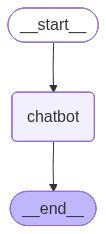

In [6]:
from IPython.display import Image, display

# Extract the graph structure and render it as a PNG image
try:
    display(Image(agent_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Failed to render image: {e}")